# Preprocessing Pipeline


## Preprocessing


This notebook documents the preprocessing stage of the data pipeline.
The goal is to identify distributional issues in the raw dataset, apply targeted preprocessing steps, and verify their effect before proceeding to feature engineering and target construction.

## Basic set up

We begin by loading the raw daily panel dataset and verifying its basic structure, including date coverage, ticker coverage, and key integrity constraints.

### Imports and Paths

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

RAW_PATH = "../data/processed/financial_database.parquet"
OUT_PREP_PATH = "../data/processed/financial_database_preprocessed.parquet"

### Load Data

In [29]:
df_raw = pd.read_parquet(RAW_PATH)

print("Shape:", df_raw.shape)
display(df_raw.head(3))

Shape: (27650, 36)


,date,open,high,low,close,adj_close,volume,sma_50,sma_200,ema_20,price_sma_50,rsi_14,macd,macd_signal,volatility_20d,ret_1d,ret_5d,ret_21d,net_margin,operating_margin,ebitda_margin,asset_turnover,roe,roa,fcf_margin,revenue_growth_qoq,earnings_growth_qoq,fcf_growth_qoq,debt_to_equity,current_ratio,effective_date,macro_effective_date,CPIAUCSL,FEDFUNDS,GDP,ticker
0,2015-01-02,27.847500,27.860001,26.837500,27.332500,24.237553,212818400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.201007,0.265057,0.321819,0.181691,0.075905,0.036521,0.223109,0.125321,0.092798,0.201176,0.316414,1.012057,2014-11-29,2015-01-01,NaN,0.11,NaN,AAPL
1,2015-01-02,15.629000,15.737500,15.348000,15.426000,15.426000,55664000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.021235,-0.026435,0.027455,0.509142,-0.042279,-0.010812,0.018854,0.064064,2.468254,-1.906542,0.383417,0.891085,2014-11-29,2015-01-01,NaN,0.11,NaN,AMZN
2,2015-01-02,26.629999,26.790001,26.393999,26.477501,26.278944,26480000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.165769,0.225383,0.328572,0.131363,0.027718,0.021776,0.216486,0.035600,-0.182632,0.199933,0.053018,4.470703,2014-11-29,2015-01-01,NaN,0.11,NaN,GOOGL


### Structural Cheks

In [30]:
print("Date range:", df_raw["date"].min(), "→", df_raw["date"].max())
print("Tickers:", df_raw["ticker"].nunique(), sorted(df_raw["ticker"].unique())[:20])

dups = df_raw.duplicated(["date", "ticker"]).sum()
print("Duplicati (date,ticker):", dups)

Date range: 2015-01-02 00:00:00 → 2025-12-30 00:00:00
Tickers: 10 ['AAPL', 'AMZN', 'GOOGL', 'JNJ', 'KO', 'META', 'MSFT', 'NVDA', 'TSLA', 'XOM']
Duplicati (date,ticker): 0


The basic checks pass, so we now focus on issues that can bias models or break assumptions if left untreated.

## Exploration of numerical columns

This section provides an exploratory analysis of numerical variables to assess scale, dispersion, and the presence of potential issues such as outliers or structural missing values.
The analysis is used to motivate preprocessing choices rather than to discover predictive patterns.

### Statistics summary

We report summary statistics for numerical features, including percentiles, to identify variables with extreme values, heavy tails, or scale heterogeneity.
These statistics guide the selection of variables requiring stabilization during preprocessing.

In [ ]:
# Divide columns into groups (explicit lists to avoid order assumptions)
price_cols = [c for c in ["open","high","low","close","adj_close","volume"] if c in df_raw.columns]

technical_cols = [
    "sma_200",
    "price_sma_200",
    "mom_3m",
    "mom_6m",
    "mom_12m",
    "volatility_20d",
    "volatility_60d",
    "ret_1d",
    "ret_21d",
]
technical_cols = [c for c in technical_cols if c in df_raw.columns]

fund_cols = [
    "operating_margin",
    "gross_margin",
    "roe",
    "roa",
    "revenue_growth_yoy",
    "earnings_growth_yoy",
    "debt_to_equity",
    "interest_coverage",
    "asset_turnover",
    "fcf_assets",
]
fund_cols = [c for c in fund_cols if c in df_raw.columns]

macro_cols = ["CPIAUCSL", "INDPRO", "DGS10", "DGS2", "STLFSI4"]
macro_cols = [c for c in macro_cols if c in df_raw.columns]


In [58]:
stats = df_raw[technical_cols].describe(percentiles=[.01, .05, .5, .95, .99]).T
display(stats.drop('count', axis=1))

,mean,std,min,1%,5%,50%,95%,99%,max
sma_50,117.907060,111.222783,0.500657,0.780211,9.637226,90.135773,328.556223,571.492896,752.801176
sma_200,115.559743,103.947244,0.526863,1.125647,9.841413,90.909590,308.511286,521.276316,677.565582
ema_20,117.863762,112.309378,0.476049,0.767165,9.089176,88.629944,331.411922,569.628389,760.460375
price_sma_50,1.023488,0.086349,0.550198,0.785323,0.894122,1.021181,1.159073,1.289684,1.952599
rsi_14,54.470204,16.784288,3.180121,17.222952,26.544898,54.677312,81.803148,90.883038,100.000000
macd,0.659751,4.085623,-35.583228,-11.268364,-3.879021,0.274323,6.215110,15.880037,40.538606
macd_signal,0.656913,3.849445,-32.238555,-10.722013,-3.659697,0.274547,5.868107,15.194683,34.756622
volatility_20d,0.018575,0.011592,0.002749,0.004853,0.006619,0.015425,0.041729,0.060507,0.100268
ret_1d,0.001115,0.021821,-0.263901,-0.060579,-0.031042,0.000908,0.032797,0.065241,0.298067
ret_5d,0.005559,0.047652,-0.430459,-0.126232,-0.066365,0.004881,0.078330,0.147389,0.564756


Technical indicators derived from prices (SMA, EMA) exhibit a wide numerical range, reflecting differences in price levels across assets rather than meaningful cross-sectional information. For this reason, absolute moving averages are not directly comparable across stocks, while normalized indicators such as the price-to-SMA ratio show stable and interpretable distributions and do not require additional preprocessing. Momentum indicators with bounded theoretical ranges (e.g. RSI) respect their expected limits and are therefore left unchanged. Conversely, return series display heavy tails and extreme values, which are economically meaningful and represent genuine market shocks; consequently, no clipping or winsorization is applied to return-based features. 

In [59]:
stats = df_raw[fund_cols].describe(percentiles=[.01, .05, .5, .95, .99]).T
display(stats.drop('count', axis=1))

,mean,std,min,1%,5%,50%,95%,99%,max
net_margin,0.185465,0.158147,-0.530478,-0.246081,-0.061304,0.200593,0.391108,0.555807,1.219053
operating_margin,0.221817,0.156071,-0.583956,-0.187431,-0.013099,0.249545,0.449013,0.611070,0.649247
ebitda_margin,0.300659,0.149816,-0.096024,-0.053023,0.075363,0.318766,0.535671,0.656505,0.712876
asset_turnover,0.187341,0.085478,0.075510,0.085465,0.103167,0.160045,0.352470,0.476508,0.552103
roe,0.073727,0.095605,-0.294227,-0.178075,-0.037166,0.062650,0.285844,0.434208,0.544204
roa,0.032990,0.032429,-0.068104,-0.030709,-0.010812,0.028223,0.074811,0.187736,0.201108
fcf_margin,0.177345,0.177263,-0.635941,-0.495193,-0.113687,0.196607,0.413311,0.479277,0.594322
revenue_growth_qoq,0.048953,0.165196,-0.414572,-0.324884,-0.185162,0.041032,0.307499,0.705152,0.878059
earnings_growth_qoq,-0.023046,4.110102,-76.647059,-3.846174,-1.074621,0.038690,1.287507,5.101266,28.514706
fcf_growth_qoq,0.214970,3.678356,-36.603448,-7.416172,-1.658919,-0.048683,2.452261,16.303797,38.220588


Fundamental variables show markedly different behavior. Profitability margins and return ratios present asymmetric distributions with extreme values exceeding economically plausible bounds, reflecting accounting effects and non-recurring events rather than persistent firm characteristics. Growth rates, particularly earnings and free cash flow growth, exhibit very large dispersion and extreme values driven by base effects when the prior-period denominator is small or negative. These observations motivate the use of domain-aware clipping and cross-sectional winsorization to stabilize fundamental features while preserving relative information.

In [69]:
stats = df_raw[macro_cols].describe(percentiles=[.01, .05, .5, .95, .99]).T
display(stats)

,count,mean,std,min,1%,5%,50%,95%,99%,max
CPIAUCSL,13510.0,271.498043,29.422345,234.747,235.342,237.498,259.127,320.580,325.031,326.030
FEDFUNDS,13030.0,2.037045,1.923280,0.050,0.050,0.080,1.550,5.330,5.330,5.330
GDP,1430.0,22985.692245,3941.043375,18063.529,18063.529,18063.529,21751.238,30042.113,30042.113,30042.113


Macroeconomic variables display smooth distributions with no abnormal outliers. The main issue is their lower publication frequency, reflected in the count column, which results in structurally missing values in the daily panel. As these variables represent the economic environment known to market participants until the next release, they are forward-filled during preprocessing, without applying any additional distributional transformation.

### Visual exploration

After inspecting summary statistics (mean, std, percentiles), we use a targeted set of visualizations to:
- confirm distributional properties (bounded vs unbounded variables),
- identify heavy tails and outliers that motivate clipping/winsorization,
- justify why some variables are left untouched (e.g., returns),
- characterize macro series as smooth, low-frequency signals.

The goal is not to plot every column, but to visualize the variables that directly support preprocessing decisions.

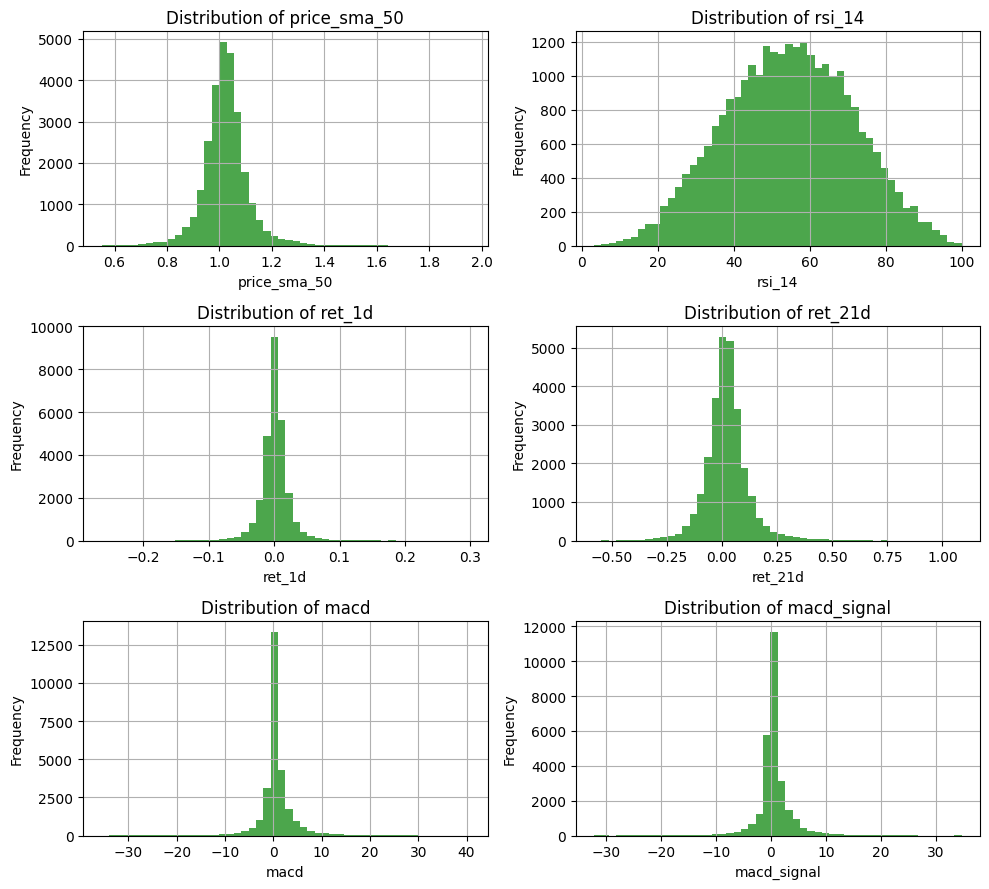

In [71]:
# technical distributions (2 plots per row, smaller)
interesting_cols = [
    "price_sma_200",
    "mom_3m",
    "mom_6m",
    "mom_12m",
    "volatility_20d",
    "volatility_60d",
    "ret_1d",
    "ret_21d",
]
interesting_cols = [c for c in interesting_cols if c in df_raw.columns]

n = len(interesting_cols)
ncols = 2
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(10, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(interesting_cols):
    ax = axes[i]
    ax.hist(df_raw[col].dropna(), bins=50, color='green', alpha=0.7)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.grid(True)

# turn off any unused subplots
for j in range(n, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


We visualize a small subset of technical features that are informative about preprocessing decisions:

- **Normalized ratios** (e.g., `price_sma_200`) should be centered and stable across assets.
- **Momentum features** (`mom_3m/6m/12m`) should have symmetric heavy tails but plausible ranges.
- **Volatility** should be strictly non-negative and higher in the tails.
- **Returns** show heavy tails but should not be clipped in preprocessing.


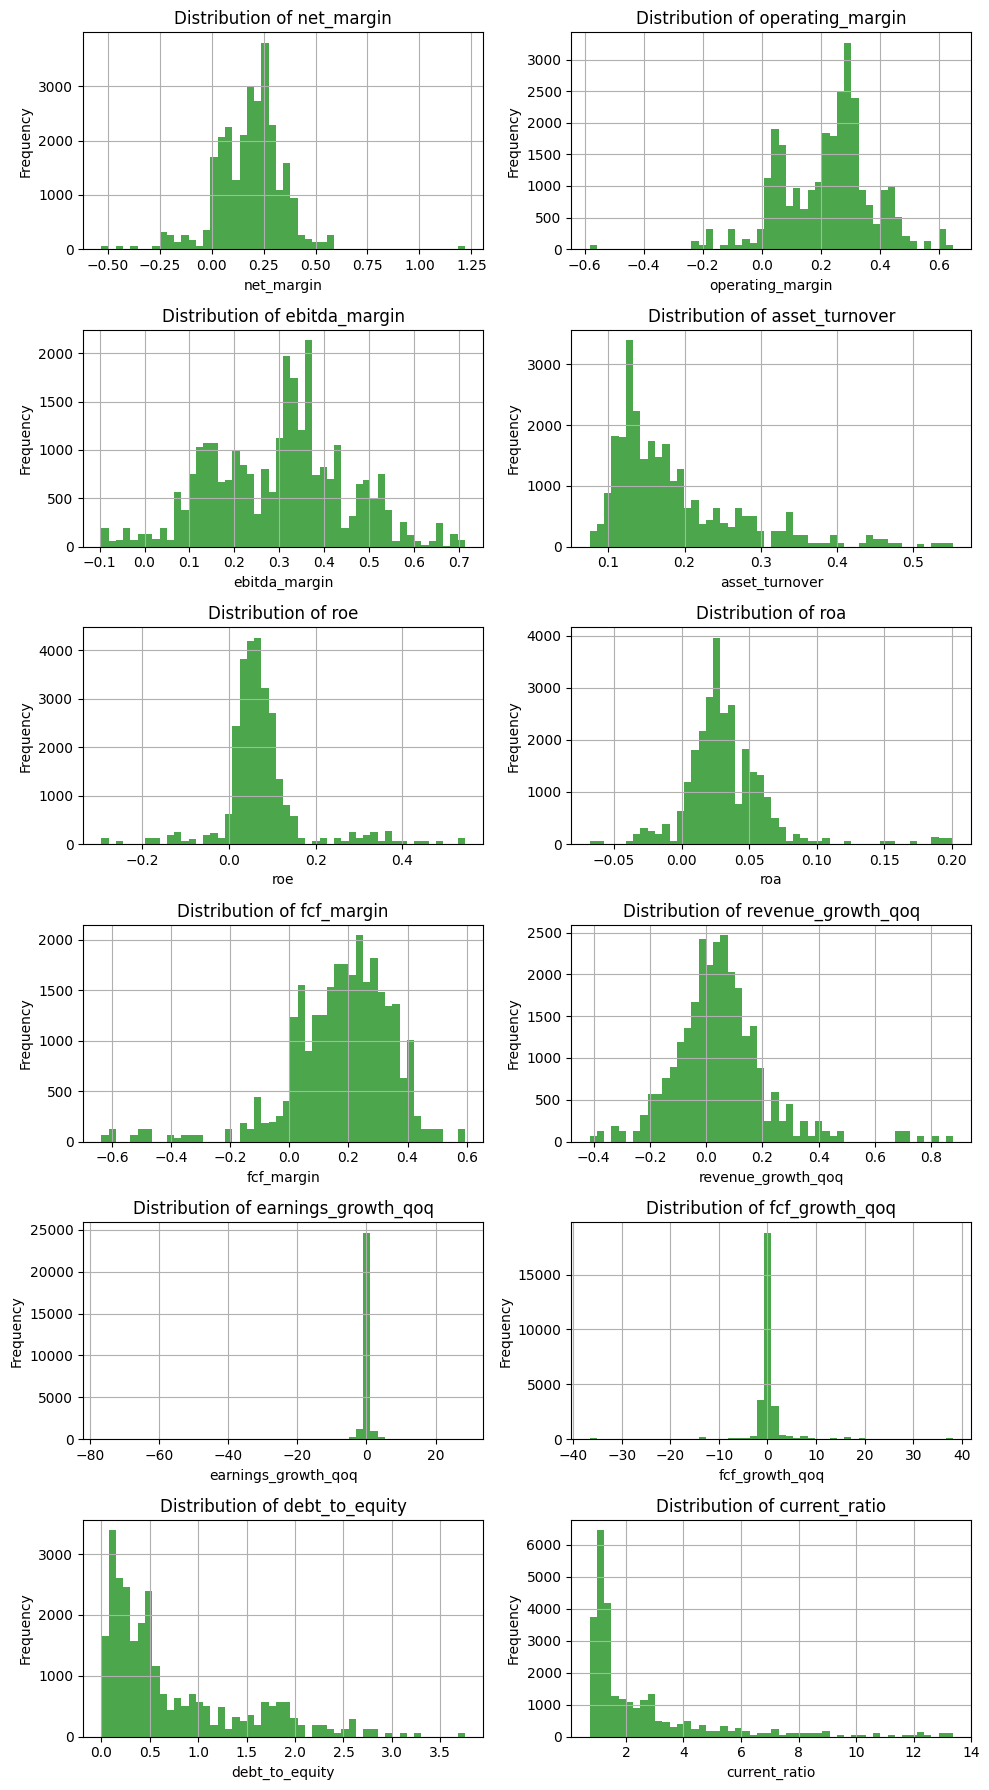

In [68]:
# fundamental distributions (2 plots per row, smaller)
n = len(fund_cols)
ncols = 2
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(10, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(fund_cols):
    ax = axes[i]
    ax.hist(df_raw[col].dropna(), bins=50, color='green', alpha=0.7)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.grid(True)

# turn off any unused subplots
for j in range(n, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Fundamental variables often exhibit outliers due to accounting effects, small denominators, and non-recurring events.
This section visualizes the most critical fundamentals to justify **domain-based clipping** and/or **cross-sectional winsorization**:

- margins (potential extreme values outside plausible bounds),
- ROE (instability when equity is small),
- growth rates (base effects leading to extreme values),
- leverage ratios (long right tails).

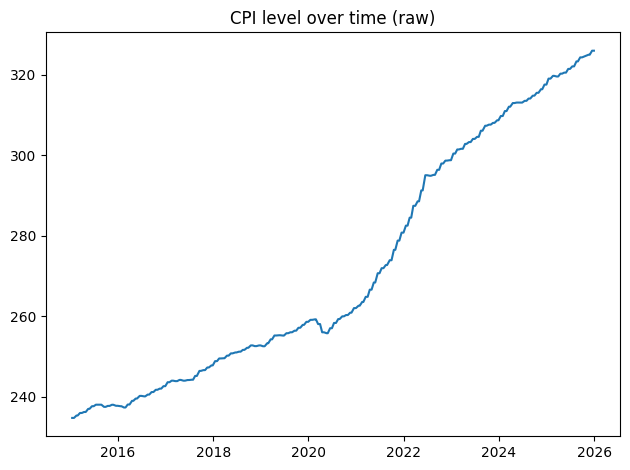

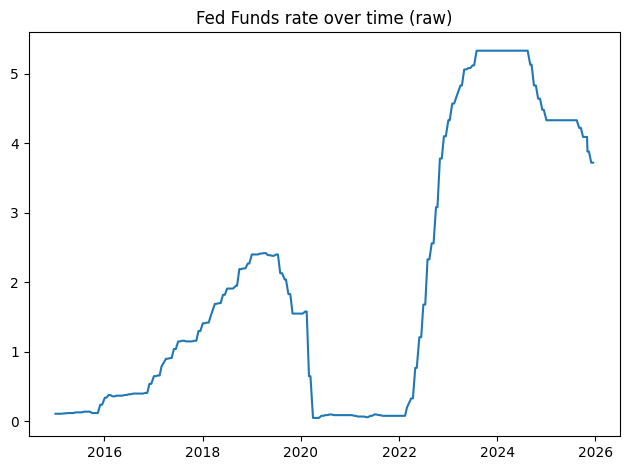

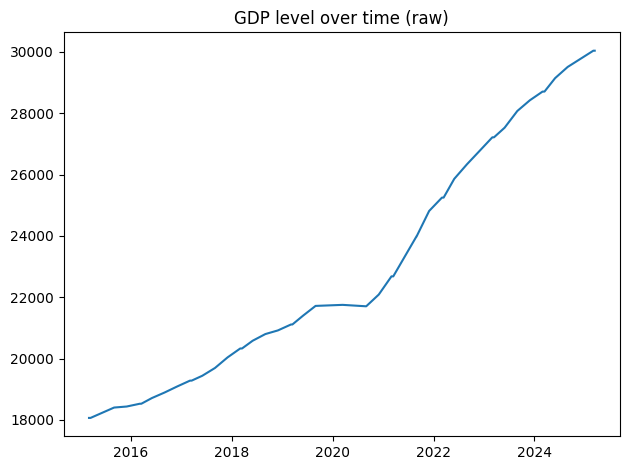

In [65]:
def line_plot(df, x_col, y_col, title):
    plt.figure()
    tmp = df[[x_col, y_col]].dropna().sort_values(x_col)
    plt.plot(tmp[x_col], tmp[y_col])
    plt.title(title)
    plt.tight_layout()
    plt.show()

ticker0 = df_raw["ticker"].iloc[0]
tmp_macro = df_raw[df_raw["ticker"] == ticker0].copy()

line_plot(tmp_macro, "date", "CPIAUCSL", "CPI level over time (raw)")
line_plot(tmp_macro, "date", "FEDFUNDS", "Fed Funds rate over time (raw)")
line_plot(tmp_macro, "date", "GDP", "GDP level over time (raw)")

Macroeconomic series are official, smooth signals with no abnormal outliers.
The main issue is their lower publication frequency, which creates structurally missing values in a daily panel.
We therefore visualize them over time to emphasize smooth dynamics.


## Potential Problems

Based on the summary statistics, we identify the main distributional issues affecting the dataset.

### Overall NaN Rate

A high NaN rate can indicate misaligned joins or sparse macro releases. Macro series update monthly/quarterly, so after the merge many dates inherit NaNs; we must forward-fill or align to release dates in preprocessing to avoid losing large portions of data. As for the other columns with NaN vaues, we assume this is perfectly normal, as all of them are rolling features.

In [31]:
nan_rate = df_raw.isna().mean().sort_values(ascending=False)
display(nan_rate.head(15))


GDP               0.948282
FEDFUNDS          0.528752
CPIAUCSL          0.511392
sma_200           0.072333
price_sma_50      0.018083
sma_50            0.018083
debt_to_equity    0.015949
ret_21d           0.007957
volatility_20d    0.007595
rsi_14            0.005425
ret_5d            0.002170
ret_1d            0.000723
macd              0.000362
macd_signal       0.000362
ema_20            0.000362
dtype: float64

### Volume Distribution

Raw volume is highly skewed with extreme spikes. This can dominate model loss and distort scaling, so we typically apply a log transform (e.g., log1p) or robust scaling before training.

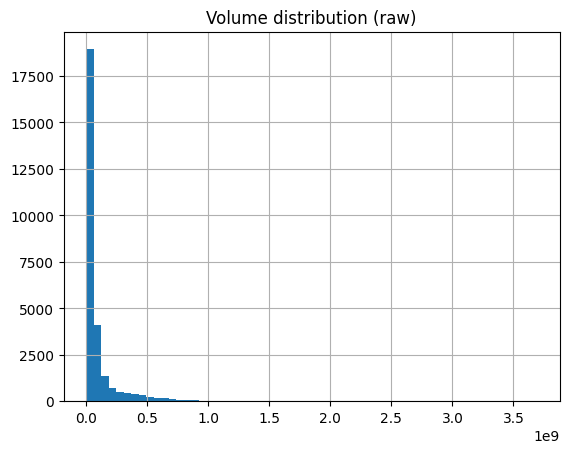

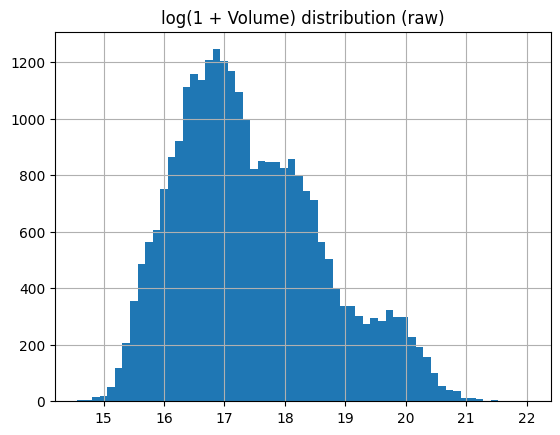

In [32]:
plt.figure()
df_raw["volume"].dropna().hist(bins=60)
plt.title("Volume distribution (raw)")
plt.show()

plt.figure()
np.log1p(df_raw["volume"].dropna()).hist(bins=60)
plt.title("log(1 + Volume) distribution (raw)")
plt.show()


### Outliers in Fundamental Features

Unlike market-based variables, fundamental ratios are derived from accounting data and are therefore more prone to extreme values.
Outliers in this context often arise from:
- small or negative denominators (e.g. equity or earnings close to zero),
- non-recurring accounting events,
- base effects in growth rates.

As shown by the distributional statistics and boxplots, several fundamental variables exhibit heavy tails and values that exceed economically plausible bounds.
These extreme observations do not represent persistent firm characteristics and may disproportionately influence cross-sectional ranking models.

For this reason, domain-aware clipping and cross-sectional winsorization are applied during preprocessing to stabilize fundamental features while preserving relative information across firms.

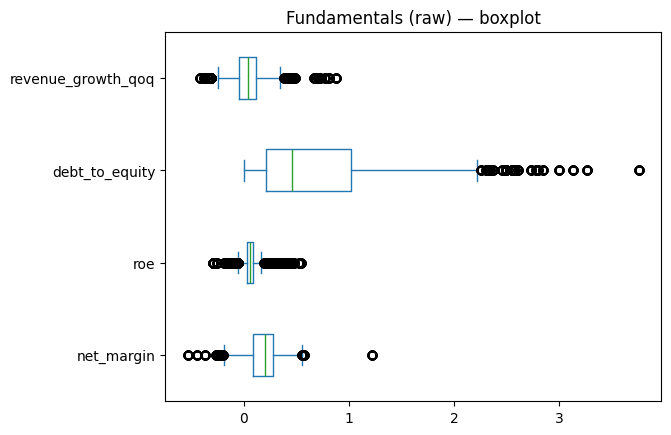

In [75]:
cols_box = ["operating_margin", "roe", "debt_to_equity", "revenue_growth_yoy", "delta_roe_yoy"]
cols_box = [c for c in cols_box if c in df_raw.columns]
if cols_box:
    df_raw[cols_box].plot(kind="box", vert=False)
    plt.title("Fundamentals (raw) — boxplot")
    plt.show()
else:
    print("No fundamental columns found for boxplot.")


## Preprocessing

Based on the issues identified above, we apply a preprocessing step that stabilizes fundamental variables and propagates macroeconomic information forward in time. No standardization is applied at this stage, as scaling choices are model-dependent and deferred to the modeling phase.
The preprocessing logic is implemented as a reusable function and is applied to the raw dataset using the configuration defined below.

### Importing the function

Function is imported from `REPO_ROOT/src/preprocessing/preprocessing.py`

In [72]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))
  
from src.preprocessing.preprocessing import preprocess_daily_panel, PreprocessConfig


### Config and Run

Choosing the right configuration for the preprocess is fundamental. For this reason we have the `PreprocessConfig` class, where parameters such as columns and the minimum non-NaN ratio can be indicated.

In [73]:
cfg = PreprocessConfig(
    macro_cols=macro_cols,
    growth_cols=["revenue_growth_yoy", "earnings_growth_yoy"],
    margin_cols=["operating_margin", "gross_margin"],
    fundamental_cols=[
        "operating_margin",
        "gross_margin",
        "roe",
        "roa",
        "asset_turnover",
        "debt_to_equity",
        "interest_coverage",
        "revenue_growth_yoy",
        "earnings_growth_yoy",
        "fcf_assets",
        "delta_roe_yoy",
    ],
    min_non_na_ratio=0.90,
)

df_prep = preprocess_daily_panel(df_raw, config=cfg)

print("Raw shape:", df_raw.shape)
print("Prep shape:", df_prep.shape)


Raw shape: (27650, 36)
Prep shape: (27650, 37)


/Users/igordragone/projects/hybrid-stock-prediction-thesis/src/preprocessing/preprocessing.py:177: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = out.groupby(date_col, group_keys=False).apply(_clip_group)


,date,open,high,low,close,adj_close,volume,sma_50,sma_200,ema_20,price_sma_50,rsi_14,macd,macd_signal,volatility_20d,ret_1d,ret_5d,ret_21d,net_margin,operating_margin,ebitda_margin,asset_turnover,roe,roa,fcf_margin,revenue_growth_qoq,earnings_growth_qoq,fcf_growth_qoq,debt_to_equity,current_ratio,effective_date,macro_effective_date,CPIAUCSL,FEDFUNDS,GDP,ticker,log_volume
0,2015-01-02,27.847500,27.860001,26.837500,27.332500,24.237553,212818400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.201007,0.265057,0.321819,0.181691,0.074765,0.036470,0.223109,0.123996,0.092798,0.201176,0.316414,1.012057,2014-11-29,2015-01-01,NaN,0.11,NaN,AAPL,19.175950
1,2015-01-02,15.629000,15.737500,15.348000,15.426000,15.426000,55664000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.021235,-0.026435,0.027455,0.489650,-0.042279,-0.010812,0.018854,0.064064,2.000000,-0.500000,0.383417,0.891085,2014-11-29,2015-01-01,NaN,0.11,NaN,AMZN,17.834844
2,2015-01-02,26.629999,26.790001,26.393999,26.477501,26.278944,26480000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.165769,0.225383,0.328572,0.131363,0.027718,0.021776,0.216486,0.035600,-0.182632,0.199933,0.053018,4.470703,2014-11-29,2015-01-01,NaN,0.11,NaN,GOOGL,17.091900


## Results

After preprocessing, we reassess missing values and distributions to verify that the identified issues have been resolved.
This validation ensures that the dataset is stable and suitable for subsequent feature engineering.

### Nan Rate

We first re-evaluate the proportion of missing values across all features.
Remaining NaNs are expected and primarily associated with rolling technical indicators during their initial warm-up periods.
No additional imputation is performed at this stage.

In [77]:
nan_rate_prep = df_prep.isna().mean().sort_values(ascending=False)
display(nan_rate_prep.head(15))

sma_200           0.072333
sma_50            0.018083
price_sma_50      0.018083
debt_to_equity    0.015949
GDP               0.014105
ret_21d           0.007957
volatility_20d    0.007595
rsi_14            0.005425
CPIAUCSL          0.003617
ret_5d            0.002170
ret_1d            0.000723
macd_signal       0.000362
macd              0.000362
ema_20            0.000362
current_ratio     0.000000
dtype: float64

In [78]:
print("Macro NaN (raw):")
display(df_raw[macro_cols].isna().mean())

print("\nMacro NaN (prep):")
display(df_prep[macro_cols].isna().mean())

Macro NaN (raw):


CPIAUCSL    0.511392
FEDFUNDS    0.528752
GDP         0.948282
dtype: float64


Macro NaN (prep):


CPIAUCSL    0.003617
FEDFUNDS    0.000000
GDP         0.014105
dtype: float64

After forward propagation, macroeconomic variables exhibit a negligible proportion of missing values.
Residual NaNs are confined to the initial part of the sample, before the first historical release, and are therefore structurally unavoidable.

### Fundamental Outliers

We reassess the statistics of fundamental variables after applying domain-based clipping and winsorization.
Extreme values observed in the raw data are substantially reduced, while the central mass and relative ordering of firms are preserved.
This confirms the effectiveness of the stabilization step.

In [79]:
desc_raw = df_raw[fund_cols].describe(percentiles=[.01, .05, .5, .95, .99]).T
desc_prep = df_prep[fund_cols].describe(percentiles=[.01, .05, .5, .95, .99]).T

print("RAW percentiles:")
display(desc_raw[["min", "1%", "5%", "50%", "95%", "99%", "max"]])

print("\nPREP percentiles:")
display(desc_prep[["min", "1%", "5%", "50%", "95%", "99%", "max"]])

RAW percentiles:


,min,1%,5%,50%,95%,99%,max
net_margin,-0.530478,-0.246081,-0.061304,0.200593,0.391108,0.555807,1.219053
operating_margin,-0.583956,-0.187431,-0.013099,0.249545,0.449013,0.611070,0.649247
ebitda_margin,-0.096024,-0.053023,0.075363,0.318766,0.535671,0.656505,0.712876
asset_turnover,0.075510,0.085465,0.103167,0.160045,0.352470,0.476508,0.552103
roe,-0.294227,-0.178075,-0.037166,0.062650,0.285844,0.434208,0.544204
roa,-0.068104,-0.030709,-0.010812,0.028223,0.074811,0.187736,0.201108
fcf_margin,-0.635941,-0.495193,-0.113687,0.196607,0.413311,0.479277,0.594322
revenue_growth_qoq,-0.414572,-0.324884,-0.185162,0.041032,0.307499,0.705152,0.878059
earnings_growth_qoq,-76.647059,-3.846174,-1.074621,0.038690,1.287507,5.101266,28.514706
fcf_growth_qoq,-36.603448,-7.416172,-1.658919,-0.048683,2.452261,16.303797,38.220588



PREP percentiles:


,min,1%,5%,50%,95%,99%,max
net_margin,-0.515706,-0.234413,-0.052061,0.200593,0.387901,0.537704,1.000000
operating_margin,-0.526584,-0.170503,-0.007160,0.249545,0.447564,0.599533,0.630944
ebitda_margin,-0.080599,-0.038380,0.075363,0.318766,0.532259,0.648103,0.707803
asset_turnover,0.076750,0.088472,0.103784,0.160045,0.352425,0.450146,0.525696
roe,-0.266282,-0.170333,-0.032917,0.062650,0.285844,0.405815,0.521597
roa,-0.064793,-0.027587,-0.010333,0.028223,0.074811,0.178720,0.192511
fcf_margin,-0.574907,-0.455253,-0.105477,0.196607,0.405944,0.472653,0.570936
revenue_growth_qoq,-0.392443,-0.312161,-0.183512,0.041032,0.305892,0.657968,0.809572
earnings_growth_qoq,-0.500000,-0.500000,-0.500000,0.038690,1.265387,2.000000,2.000000
fcf_growth_qoq,-0.500000,-0.500000,-0.500000,-0.048683,2.000000,2.000000,2.000000


After preprocessing, summary statistics remain largely unchanged across central percentiles, while extreme values are substantially reduced. This confirms that the preprocessing step stabilizes outliers without altering the core distribution or relative ordering of firms. The best example of this behaviour are growth features.


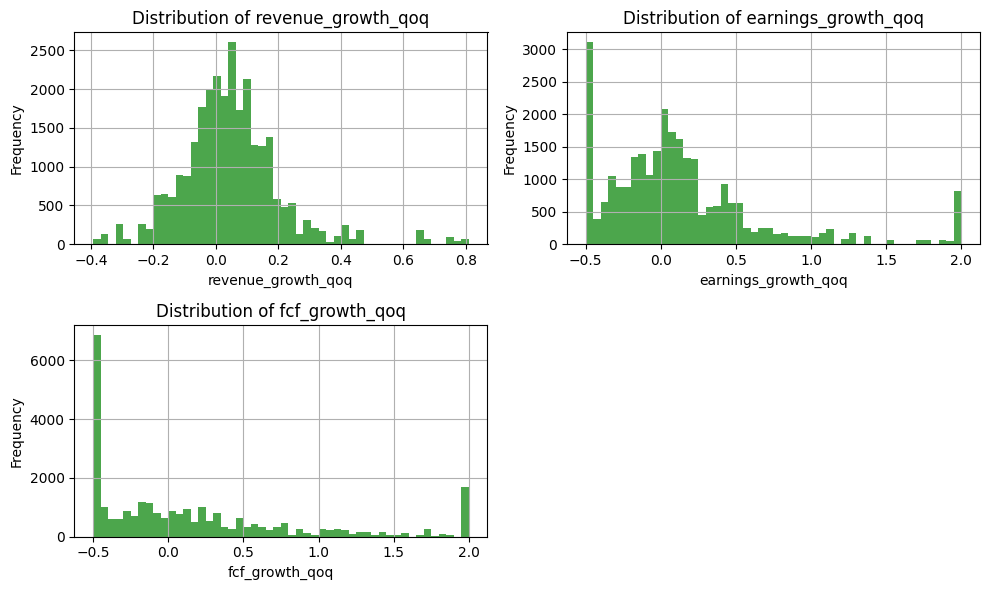

In [85]:
growth_cols = ["revenue_growth_yoy", "earnings_growth_yoy"]

growth_cols = [c for c in growth_cols if c in df_prep.columns]

n = len(growth_cols)
ncols = 2
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(10, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(growth_cols):
    ax = axes[i]
    ax.hist(df_prep[col].dropna(), bins=50, color='green', alpha=0.7)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.grid(True)

# turn off any unused subplots
for j in range(n, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


### Quick check

As a final verification, we inspect selected variables for a single representative stock, where the new feature `log_volume`is present and macroeconomic variables remain constant between releases.

In [82]:
ticker = "AAPL"
cols_show = ["date", "ticker", "log_volume", "CPIAUCSL", "FEDFUNDS", "GDP"]

tmp = df_prep[df_prep["ticker"] == ticker].sort_values("date")
display(tmp[cols_show].tail(20))

,date,ticker,log_volume,CPIAUCSL,FEDFUNDS,GDP
27450,2025-12-02,AAPL,17.798355,325.031,3.72,30042.113
27460,2025-12-03,AAPL,17.589161,325.031,3.72,30042.113
27470,2025-12-04,AAPL,17.599452,325.031,3.72,30042.113
27480,2025-12-05,AAPL,17.671298,325.031,3.72,30042.113
27490,2025-12-08,AAPL,17.458655,325.031,3.72,30042.113
27500,2025-12-09,AAPL,17.287269,325.031,3.72,30042.113
27510,2025-12-10,AAPL,17.313178,325.031,3.72,30042.113
27520,2025-12-11,AAPL,17.319505,325.031,3.72,30042.113
27530,2025-12-12,AAPL,17.492644,325.031,3.72,30042.113
27540,2025-12-15,AAPL,17.735682,325.031,3.72,30042.113


## Saving The File

The preprocessed dataset is saved as a separate Parquet file.
This ensures a clear separation between preprocessing, feature engineering, and target construction, and allows downstream steps to be reproduced without re-running earlier stages.

In [76]:
df_prep.to_parquet(OUT_PREP_PATH, index=False)
print("Saved:", OUT_PREP_PATH)

Saved: ../data/processed/financial_database_preprocessed.parquet



## Feature Engineering


This notebook derives higher-level, interpretable features from the preprocessed dataset. It focuses on regime/state representations for macro, fundamentals, and technicals, and validates their coherence before target construction.

## Basic Setup

### Imports and Paths

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

IN_PREP_PATH = "../data/processed/financial_database_preprocessed.parquet"
OUT_FEAT_PATH = "../data/processed/financial_database_features.parquet"

### Load Preprocessed Dataset

The preprocessed dataset from the prior step is loaded as the stable base for feature engineering to ensure consistency and reproducibility.

In [ ]:
df_prep = pd.read_parquet(IN_PREP_PATH)
print("Shape:", df_prep.shape)
display(df_prep.head(3))

Shape: (27650, 37)


,date,open,high,low,close,adj_close,volume,sma_50,sma_200,ema_20,price_sma_50,rsi_14,macd,macd_signal,volatility_20d,ret_1d,ret_5d,ret_21d,net_margin,operating_margin,ebitda_margin,asset_turnover,roe,roa,fcf_margin,revenue_growth_qoq,earnings_growth_qoq,fcf_growth_qoq,debt_to_equity,current_ratio,effective_date,macro_effective_date,CPIAUCSL,FEDFUNDS,GDP,ticker,log_volume
0,2015-01-02,27.847500,27.860001,26.837500,27.332500,24.237553,212818400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.201007,0.265057,0.321819,0.181691,0.074765,0.036470,0.223109,0.123996,0.092798,0.201176,0.316414,1.012057,2014-11-29,2015-01-01,NaN,0.11,NaN,AAPL,19.175950
1,2015-01-02,15.629000,15.737500,15.348000,15.426000,15.426000,55664000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.021235,-0.026435,0.027455,0.489650,-0.042279,-0.010812,0.018854,0.064064,2.000000,-0.500000,0.383417,0.891085,2014-11-29,2015-01-01,NaN,0.11,NaN,AMZN,17.834844
2,2015-01-02,26.629999,26.790001,26.393999,26.477501,26.278944,26480000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.165769,0.225383,0.328572,0.131363,0.027718,0.021776,0.216486,0.035600,-0.182632,0.199933,0.053018,4.470703,2014-11-29,2015-01-01,NaN,0.11,NaN,GOOGL,17.091900


## Feature Engineering

### Feature Set to Create

A compact, interpretable feature set is constructed:

- **Macro**: trend indicators and a four-state macro regime.
- **Fundamentals**: cross-sectional buckets (low/mid/high) and binary flags.
- **Technicals**: RSI state and a long-term trend state.

The goal is to enrich the dataset with higher-level representations while keeping the feature set minimal and interpretable.

### Generate Engineered Features

Engineered features are computed on **end-of-month (EOM) snapshots** to align with monthly rebalancing. The pipeline samples the last available observation per ticker each month, applies cross-sectional winsorization (fundamentals) and percentile ranks **at the monthly level**, and returns an **EOM-only panel**.


The feature-engineering routine is applied to the preprocessed dataset. Original columns are retained and new engineered fields are appended. The project root is added to `sys.path` to import local modules from `src/` when running the notebook.

In [8]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.preprocessing.pipeline import build_feature_panel
from src.preprocessing.preprocessing import PreprocessConfig

macro_cols = []
growth_cols = ["revenue_growth_yoy", "earnings_growth_yoy"]
margin_cols = ["operating_margin", "gross_margin"]
fundamental_cols = [
    "operating_margin",
    "gross_margin",
    "roe",
    "roa",
    "asset_turnover",
    "debt_to_equity",
    "interest_coverage",
    "revenue_growth_yoy",
    "earnings_growth_yoy",
    "fcf_assets",
    "delta_roe_yoy",
]

cfg = PreprocessConfig(
    macro_cols=macro_cols,
    growth_cols=growth_cols,
    margin_cols=margin_cols,
    fundamental_cols=fundamental_cols,
)

df_feat = build_feature_panel(df_prep, preprocess_config=cfg, preprocessed=True)

print("Preprocessed shape:", df_prep.shape)
print("With engineered features:", df_feat.shape)
display(df_feat.head(3))


Preprocessed shape: (27650, 37)
With engineered features: (27650, 49)


,date,open,high,low,close,adj_close,volume,sma_50,sma_200,ema_20,price_sma_50,rsi_14,macd,macd_signal,volatility_20d,ret_1d,ret_5d,ret_21d,net_margin,operating_margin,ebitda_margin,asset_turnover,roe,roa,fcf_margin,revenue_growth_qoq,earnings_growth_qoq,fcf_growth_qoq,debt_to_equity,current_ratio,effective_date,macro_effective_date,CPIAUCSL,FEDFUNDS,GDP,ticker,log_volume,cpi_trend,rate_trend,gdp_trend,macro_regime,margin_bucket,profitability_bucket,leverage_bucket,is_profitable,is_high_growth,is_high_leverage,rsi_state,trend_state
0,2015-01-02,27.847500,27.860001,26.837500,27.332500,24.237553,212818400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.201007,0.265057,0.321819,0.181691,0.074765,0.036470,0.223109,0.123996,0.092798,0.201176,0.316414,1.012057,2014-11-29,2015-01-01,NaN,0.11,NaN,AAPL,19.175950,0,0,0,recession,high,high,mid,1,1,1,0,<NA>
1,2015-01-02,15.629000,15.737500,15.348000,15.426000,15.426000,55664000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.021235,-0.026435,0.027455,0.489650,-0.042279,-0.010812,0.018854,0.064064,2.000000,-0.500000,0.383417,0.891085,2014-11-29,2015-01-01,NaN,0.11,NaN,AMZN,17.834844,0,0,0,recession,low,low,high,0,1,1,0,<NA>
2,2015-01-02,26.629999,26.790001,26.393999,26.477501,26.278944,26480000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.165769,0.225383,0.328572,0.131363,0.027718,0.021776,0.216486,0.035600,-0.182632,0.199933,0.053018,4.470703,2014-11-29,2015-01-01,NaN,0.11,NaN,GOOGL,17.091900,0,0,0,recession,mid,low,low,1,0,0,0,<NA>


## Exploration of the Engineered Dataset

### New Feature Columns

The list of engineered features is defined once and reused across validation checks for consistency.

In [9]:
new_cols = [
    "stress_index",
    "stress_index",
    "macro_regime",
    "roe_pr",
    "roa_pr",
    "operating_margin_pr",
    "gross_margin_pr",
    "revenue_growth_pr",
    "earnings_growth_pr",
    "delta_roe_pr",
    "debt_pr",
    "interest_coverage_pr",
    "asset_turnover_pr",
    "mom12_pr",
    "mom6_pr",
    "mom3_pr",
    "trend_ratio_pr",
    "vol_pr",
    "vol_ratio_pr",
]

missing_new = [c for c in new_cols if c not in df_feat.columns]
print("Missing engineered columns:", missing_new)


Missing engineered columns: []


### Missing Values in Engineered Features

Because the engineered dataset is **EOM-only**, missing values are no longer driven by non‑EOM rows. Any residual NaNs correspond to genuine data gaps (e.g., missing fundamentals) and are handled by the neutral fill (0.5) during percentile ranking.


Missing-value rates are inspected. Most engineered variables should be fully populated; NaNs are expected only during warm-up periods for rolling features (e.g., SMA200-based trend state).

In [10]:
display(df_feat[new_cols].isna().mean().sort_values(ascending=False))

trend_state             0.072333
leverage_bucket         0.015949
cpi_trend               0.000000
rate_trend              0.000000
gdp_trend               0.000000
macro_regime            0.000000
margin_bucket           0.000000
profitability_bucket    0.000000
is_profitable           0.000000
is_high_growth          0.000000
is_high_leverage        0.000000
rsi_state               0.000000
dtype: float64

### Macro Regime Coherence

The distribution and temporal stability of macro regimes and trend indicators are inspected to confirm a coherent macro representation.

### Annual Macro Regime Summary
Summarize the dominant macro regime by year and note any secondary regimes with their date ranges.

In [27]:
def summarize_macro_regimes(df, date_col="date", regime_col="macro_regime"):
    if regime_col not in df.columns:
        print("macro_regime column not found.")
        return
    d = df[[date_col, regime_col]].dropna().copy()
    d[date_col] = pd.to_datetime(d[date_col])
    d = d.sort_values(date_col)
    d["year"] = d[date_col].dt.year

    for year, g in d.groupby("year"):
        counts = g[regime_col].value_counts()
        if counts.empty:
            continue
        main_regime = counts.idxmax()
        main_share = counts.max() / counts.sum()

        # build contiguous regime blocks
        blocks = []
        curr_reg = None
        start = None
        for _, row in g.iterrows():
            reg = row[regime_col]
            date = row[date_col]
            if curr_reg is None:
                curr_reg = reg
                start = date
                continue
            if reg != curr_reg:
                blocks.append((curr_reg, start, date))
                curr_reg = reg
                start = date
        blocks.append((curr_reg, start, g[date_col].iloc[-1]))

        print(f"{year} -> {main_regime} (share={main_share:.2f})")
        for reg, s, e in blocks:
            if reg != main_regime:
                print(f"  - {reg}: {s.date()} -> {e.date()}")


2015 -> recession (share=1.00)
2016 -> expansion (share=0.85)
  - recession: 2016-01-04 -> 2016-01-19
  - stagflation: 2016-01-19 -> 2016-03-01
2017 -> expansion (share=1.00)
2018 -> expansion (share=1.00)
2019 -> expansion (share=1.00)
2020 -> expansion (share=0.75)
  - stagflation: 2020-08-31 -> 2020-11-30
2021 -> expansion (share=1.00)
2022 -> expansion (share=1.00)
2023 -> expansion (share=1.00)
2024 -> expansion (share=1.00)
2025 -> expansion (share=1.00)


In [29]:
# Macro regime should be identical across tickers on the same date
regime_var = df_feat.groupby("date")["macro_regime"].nunique()
print("Days where macro_regime differs across tickers:", (regime_var > 1).sum())

display(df_feat["macro_regime"].value_counts(dropna=False))
display(df_feat["stress_index"].value_counts(dropna=False).sort_index())

# as every day is represented by multiple tickers, we only want to look at unique dates
unique_dates = df_feat[["date", "macro_regime"]].drop_duplicates().sort_values("date")
plt.figure(figsize=(12, 6))
plt.plot(unique_dates["date"], unique_dates["macro_regime"].cat.codes, lw=1)
plt.yticks(range(4), ["goldilocks", "reflation", "stagflation", "deflation"])
plt.title("Macro Regime Over Time (label codes)")
plt.tight_layout()
plt.show()


Days where macro_regime differs across tickers: 0


macro_regime
expansion      24110
recession       2620
stagflation      920
Name: count, dtype: int64

cpi_trend
0     2620
1    25030
Name: count, dtype: int64

rate_trend
-1     7750
 0     1260
 1    18640
Name: count, dtype: int64

gdp_trend
-1      630
 0     2910
 1    24110
Name: count, dtype: int64

In [33]:
print("
Macro inputs missing values:")
print(f"cpi_yoy NaNs: {df_feat['cpi_yoy'].isna().sum()}")
print(f"ip_yoy NaNs: {df_feat['ip_yoy'].isna().sum()}")



Macro Regime Value Counts:
macro_regime
expansion      24110
recession       2620
stagflation      920
Name: count, dtype: int64

Trend indicators missing values:
cpi_trend NaNs: 0
rate_trend NaNs: 0
gdp_trend NaNs: 0


### Fundamentals Buckets and Flags

Cross-sectional buckets should be reasonably balanced, and binary flags should not be degenerate (always 0 or always 1).

In [12]:
pr_cols = [
    "roe_pr",
    "roa_pr",
    "operating_margin_pr",
    "gross_margin_pr",
    "revenue_growth_pr",
    "earnings_growth_pr",
    "delta_roe_pr",
    "debt_pr",
    "interest_coverage_pr",
    "asset_turnover_pr",
    "mom12_pr",
    "mom6_pr",
    "mom3_pr",
    "trend_ratio_pr",
    "vol_pr",
    "vol_ratio_pr",
]
pr_cols = [c for c in pr_cols if c in df_feat.columns]

summary = df_feat[pr_cols].describe(percentiles=[0.01, 0.5, 0.99]).T
display(summary[["mean", "std", "1%", "50%", "99%"]])


margin_bucket
high    11060
low      8295
mid      8295
Name: count, dtype: int64

profitability_bucket
high    11060
low      8295
mid      8295
Name: count, dtype: int64

leverage_bucket
high    10619
low      8295
mid      8295
NaN       441
Name: count, dtype: int64

is_profitable
1    25744
0     1906
Name: count, dtype: int64

is_high_growth
1    13825
0    13825
Name: count, dtype: int64

is_high_leverage
0    14266
1    13384
Name: count, dtype: int64

Bucket coverage is checked across dates to ensure multiple buckets are represented each day, keeping the features meaningful for cross-sectional modeling.

In [24]:
# PR columns should be mostly within [0, 1] when using percentile ranks
for c in pr_cols:
    s = df_feat[c].dropna()
    if s.empty:
        continue
    out_of_range = ((s < 0) | (s > 1)).mean()
    print(f"{c} | out-of-range share: {out_of_range:.3f}")


margin_bucket  - days with <3 buckets: 0 out of 2765
profitability_bucket  - days with <3 buckets: 0 out of 2765
leverage_bucket  - days with <3 buckets: 0 out of 2765


### Technical States

Technical states are inspected for plausibility (e.g., RSI state distribution) along with the long-term trend state derived from price vs SMA200.

In [13]:
# Trend state remains an auxiliary diagnostic (not used in model-ready features)
if "trend_state" in df_feat.columns:
    display(df_feat["trend_state"].value_counts(dropna=False))


rsi_state
-1     2174
 0    20298
 1     5178
Name: count, dtype: int64

trend_state
1       18844
0        6806
<NA>     2000
Name: count, dtype: Int64

### Quick Inspection on a Single Ticker

A single-ticker time series is reviewed to ensure engineered features evolve coherently; this qualitative check helps catch implementation errors early.

In [14]:
ticker = "AAPL"
cols_show = ["date", "ticker"] + new_cols + ["roe", "delta_roe_yoy", "debt_to_equity", "adj_close", "sma_200"]

cols_show = [c for c in cols_show if c in df_feat.columns]

tmp = df_feat[df_feat["ticker"] == ticker].sort_values("date")
display(tmp[cols_show].tail(25))


,date,ticker,cpi_trend,rate_trend,gdp_trend,macro_regime,margin_bucket,profitability_bucket,leverage_bucket,is_profitable,is_high_growth,is_high_leverage,rsi_state,trend_state,net_margin,roe,debt_to_equity,rsi_14,adj_close,sma_200
27400,2025-11-24,AAPL,1,-1,1,expansion,mid,high,high,1,0,1,0,1,0.249202,0.347688,1.544858,55.138574,275.920013,225.819773
27410,2025-11-25,AAPL,1,-1,1,expansion,mid,high,high,1,0,1,0,1,0.249202,0.347688,1.544858,60.332919,276.970001,226.066347
27420,2025-11-26,AAPL,1,-1,1,expansion,mid,high,high,1,0,1,0,1,0.249202,0.347688,1.544858,61.561762,277.549988,226.316826
27430,2025-11-28,AAPL,1,-1,1,expansion,mid,high,high,1,0,1,0,1,0.249202,0.347688,1.544858,63.020713,278.850006,226.545440
27440,2025-12-01,AAPL,1,-1,1,expansion,mid,high,high,1,1,1,0,1,0.268050,0.362729,1.523509,67.228000,283.100006,226.759376
27450,2025-12-02,AAPL,1,-1,1,expansion,mid,high,high,1,1,1,1,1,0.268050,0.362729,1.523509,70.156314,286.190002,226.971342
27460,2025-12-03,AAPL,1,-1,1,expansion,mid,high,high,1,1,1,0,1,0.268050,0.362729,1.523509,67.543305,284.149994,227.183459
27470,2025-12-04,AAPL,1,-1,1,expansion,mid,high,high,1,1,1,0,1,0.268050,0.362729,1.523509,66.984720,280.700012,227.386025
27480,2025-12-05,AAPL,1,-1,1,expansion,mid,high,high,1,1,1,0,1,0.268050,0.362729,1.523509,61.274369,278.779999,227.569347
27490,2025-12-08,AAPL,1,-1,1,expansion,mid,high,high,1,1,1,0,1,0.268050,0.362729,1.523509,58.909084,277.890015,227.738286


### Optional Visualization

To validate `trend_state`, price and SMA200 are plotted with points colored by the trend indicator.
This is a diagnostic check and the binary state is not used in the model-ready feature set.


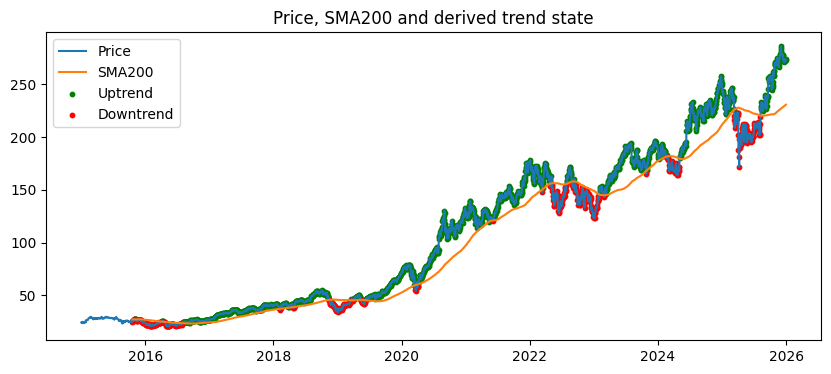

In [19]:
plt.figure(figsize=(10,4))
plt.plot(tmp["date"], tmp["adj_close"], label="Price")
plt.plot(tmp["date"], tmp["sma_200"], label="SMA200")

up = tmp["trend_state"] == 1
down = tmp["trend_state"] == 0

plt.scatter(tmp.loc[up, "date"], tmp.loc[up, "adj_close"], color="green", s=10, label="Uptrend")
plt.scatter(tmp.loc[down, "date"], tmp.loc[down, "adj_close"], color="red", s=10, label="Downtrend")

plt.legend()
plt.title("Price, SMA200 and derived trend state")
plt.show()

## Save Engineered Dataset

The engineered dataset is saved as a separate Parquet artifact for downstream target construction and modeling.

In [16]:
df_feat.to_parquet(OUT_FEAT_PATH, index=False)
print("Saved:", OUT_FEAT_PATH)

Saved: ../data/processed/financial_database_features.parquet



## Target Construction


This notebook runs the target construction module, performs a quick sanity check and realizes EDA over the target.

## Basic Setup

### Imports and Paths

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

IN_FEAT_PATH = "../data/processed/financial_database_features.parquet"
OUT_MODEL_PATH = "../data/processed/financial_database_model_ready.parquet"

Shape: (27650, 49)


### Load Dataset

In [9]:
df = pd.read_parquet(IN_FEAT_PATH)
df["date"] = pd.to_datetime(df["date"])
print("Shape:", df.shape)

Shape: (27650, 49)


## Target Construction

### Build the Target

The target is built by applying the target construction module to the **EOM engineered dataset**. Forward returns are computed in **monthly steps** (1M and 3M), and the default target score uses the **3M forward return**.


In [3]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.preprocessing.target_construction import TargetConfig, construct_target, make_model_ready

cfg = TargetConfig()

df_t = construct_target(df_feat, cfg)
df_model = make_model_ready(df_t, cfg)

print("With target:", df_t.shape)
print("Model-ready:", df_model.shape)


With target: (27650, 53)
Model-ready: (27020, 53)


## Exploratory Data Analysis

This section continues with a compact EDA of the model-ready dataset, focusing on target behavior, forward returns, and signal diagnostics.

### Sanity Check

#### NaN ratios

Check the proportion of missing targets. NaNs are expected near the dataset tail because forward returns cannot be computed beyond the available date range.

In [14]:
print("Percentage of missing target values:", df_t["target_3m"].isna().mean() * 100)
print("First date with missing target values:", df_t[df_t["target_3m"].isna()]["date"].min())

Percentage of missing target values: 2.278481012658228
First date with missing target values: 2025-10-01 00:00:00


#### Overall Class Balance

Inspect the distribution of the continuous target (target_3m).


In [16]:
df_t["target_3m"].describe()


target
-1.0    0.3
 0.0    0.4
 1.0    0.3
Name: proportion, dtype: float64

#### Class Balance Over Time

Check how the target mix evolves by year to detect temporal drift.

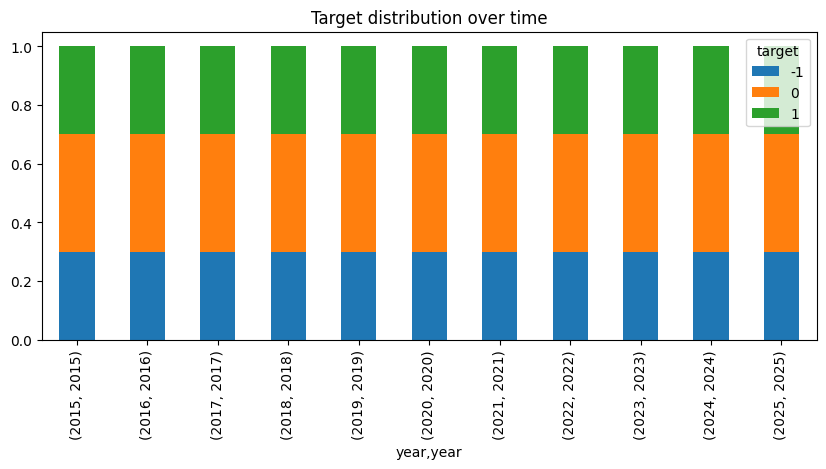

In [ ]:
(
    df_t
    .assign(year=df_t["date"].dt.year)
    .groupby("year")["target_3m"]
    .mean()
    .plot(kind="bar", figsize=(10,4))
)
plt.title("Average target_3m by year")
plt.show()


#### Forward return separation by class

Validate coherence by confirming that larger target_3m values correspond to larger forward returns on average.


<Figure size 640x480 with 0 Axes>

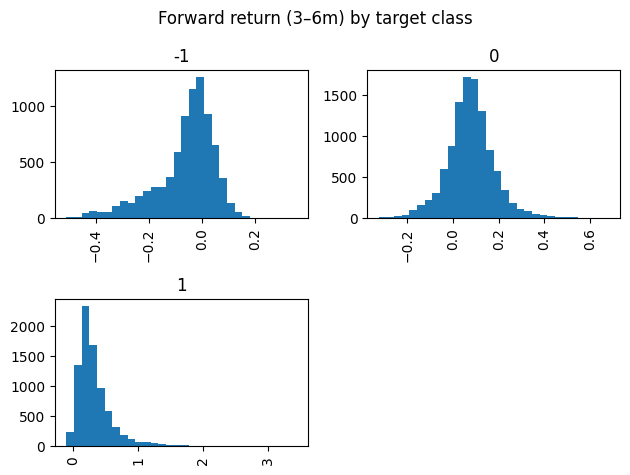

,count,mean,std,min,10%,50%,90%,max
target,,,,,,,,
-1,8106.0,-0.060872,0.112634,-0.511265,-0.225328,-0.035077,0.054070,0.354357
0,10808.0,0.077942,0.105705,-0.324468,-0.042247,0.075409,0.200020,0.680031
1,8106.0,0.330909,0.291410,-0.104325,0.083479,0.259230,0.645452,3.430250


In [15]:
tmp = df_model.copy()

plt.figure()
tmp["target_3m"].hist(bins=30, grid=False)
plt.title("Distribution of target_3m")
plt.tight_layout()
plt.show()

tmp["target_3m"].describe(percentiles=[.1, .5, .9])


### Information Coefficient Utility

Define a helper to compute per-date Spearman IC between a feature and a forward return.

In [22]:
def compute_ic(df, feature, ret_col):
    ic = (
        df
        .groupby("date")
        .apply(lambda x: x[feature].corr(x[ret_col], method="spearman"), include_groups=False)
    )
    return ic

#### Example IC: ROE vs Forward Returns

Compute the IC distribution for a representative fundamental feature.

In [27]:
import scipy
ic_roe = compute_ic(df_t, "roe", "fwd_ret_3m")

print("Mean IC (ROE):", ic_roe.mean())
print("Standatd deviation IC (ROE):", ic_roe.std())
print("Information Ratio (ROE):", ic_roe.mean() / ic_roe.std())

Mean IC (ROE): 0.028791243299015307
Standatd deviation IC (ROE): 0.34907715974586717
Information Ratio (ROE): 0.08247816419720991


#### Rolling IC Stability
Inspect the rolling mean IC to evaluate temporal stability of the signal.

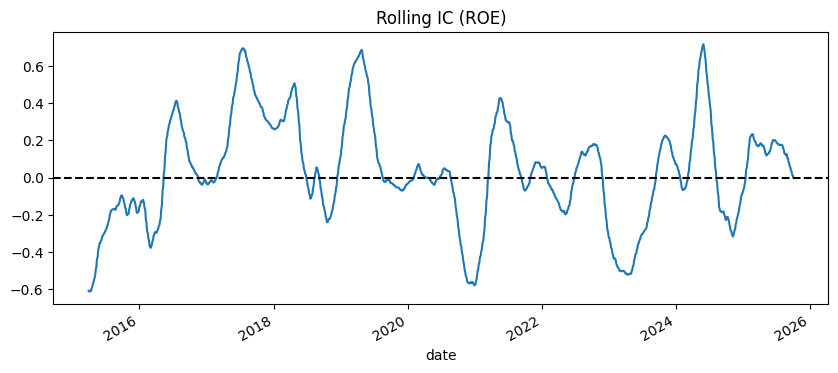

In [19]:
ic_roe.rolling(60).mean().plot(figsize=(10,4))
plt.axhline(0, color="black", linestyle="--")
plt.title("Rolling IC (ROE)")
plt.show()

### Macro Interaction

#### Forward Returns by Macro Regime and Target

Compare average forward returns across macro regimes to validate regime effects.

/var/folders/s6/9f3nj5t50b1f2ytqq5m43b4r0000gn/T/ipykernel_42174/594733292.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["macro_regime", "target"])


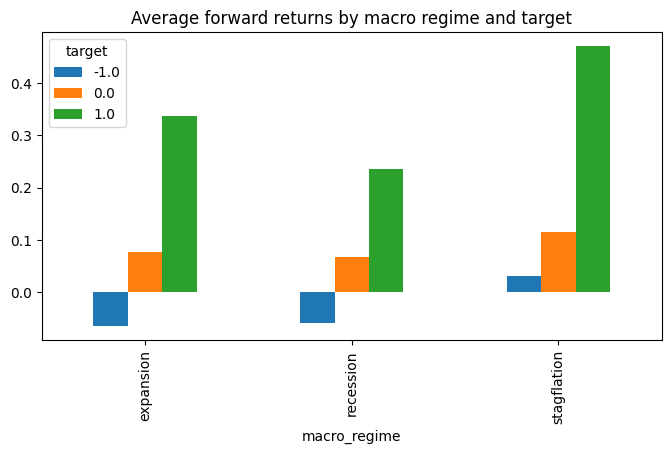

In [25]:
(
    df_t
    .groupby("macro_regime")["target_3m"]
    .mean()
    .plot(kind="bar", figsize=(8,4))
)
plt.title("Average target_3m by macro regime")
plt.show()


### Cross-Sectional Robustness

#### Per-Ticker Correlation Check

Inspect the distribution of per-ticker correlations to ensure the signal is not driven by a single name.

In [26]:
(
    df_t
    .groupby("ticker")
    .apply(lambda x: x["roe"].corr(x["fwd_ret_3m"], method="spearman"))
    .sort_values()
)


/var/folders/s6/9f3nj5t50b1f2ytqq5m43b4r0000gn/T/ipykernel_42174/3652313200.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x["roe"].corr(x["fwd_ret_3m"], method="spearman"))


ticker
AMZN    -0.361240
NVDA    -0.335617
META    -0.200360
KO      -0.101005
GOOGL   -0.086634
TSLA    -0.084238
MSFT    -0.016300
AAPL     0.002643
JNJ      0.020891
XOM      0.123411
dtype: float64

## Save new dataset

In [ ]:
df_model.to_parquet(OUT_MODEL_PATH, index=False)
print("Saved:", OUT_MODEL_PATH)